In [1]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Generate independent variables
marketing_spend = np.random.uniform(1000, 5000, 30)  # Marketing Spend in dollars
store_traffic = np.random.randint(200, 1000, 30)  # Number of customers visiting
regions = np.random.choice(['North', 'South', 'East', 'West'], 30)  # Categorical variable
weather = np.random.choice(['Sunny', 'Rainy', 'Cloudy'], 30)  # Categorical variable

# Generate dependent variable (Sales) with some base formula and initial noise
sales = 50 + 0.05 * marketing_spend + 0.1 * store_traffic + np.random.normal(0, 30, 30)  # Adding noise

# Add more noise to Sales
noise_factor = np.random.normal(0, 40, 30)  # Additional noise level
sales = sales + noise_factor

# Create DataFrame
df = pd.DataFrame({
    'Marketing Spend': marketing_spend,
    'Store Traffic': store_traffic,
    'Region': regions,
    'Weather': weather,
    'Sales': sales
})

# Display the DataFrame
df


,Marketing Spend,Store Traffic,Region,Weather,Sales
0,2498.160475,846,East,Sunny,282.527972
1,4802.857226,220,South,Sunny,312.121643
2,3927.975767,366,South,Sunny,297.777444
3,3394.633937,473,West,Cloudy,261.215509
4,1624.074562,587,South,Sunny,209.718177
5,1623.978081,800,South,Sunny,197.246685
6,1232.334449,515,South,Sunny,86.098587
7,4464.704583,213,West,Cloudy,332.223811
8,3404.460047,441,South,Sunny,293.365372
9,3832.290311,976,East,Sunny,337.794479


In [20]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.stats import linregress

x = df['Sales']
y= df['Marketing Spend']

Slope ,intersept,r_value, p_value,std_err = linregress(x,y)

print(Slope,intersept,r_value,p_value,std_err)


10.376861780533357 262.5910805206704 0.7202281090627562 7.209361483313792e-06 1.8889132296443216


In [24]:
pridicted_y = Slope * x + intersept
pridicted_y

 model is performing we use SSR(Sum of Squares of Regression), SST(Sum of Squares of Errors), and SSE (Total Sum of Squares):SST = SSR + SSE.

 I’ll explain using a text-based graph representation. Let's break it down step by step.  

---

### **1. Understanding Variance in \( Y \) (SST - Total Variance)**
Variance in \( Y \) represents how spread out the actual data points are from their mean \( \bar{Y} \). If the actual values are very close to the mean, the variance is small; if they are spread out widely, the variance is large.  

#### **Graph Representation of Variance in \( Y \)**  
Consider these five actual data points (●) along the \( Y \)-axis:  

```
 Y-axis ↑
  |
10|       ●   
  |       
  |       ●   
  |       
  |       ●   Mean (Ȳ)  
  |       
  |       ●   
  |       
  |       ●   
  +-------------------> X-axis
```
- The **horizontal dashed line** represents the mean \( \bar{Y} \).  
- The vertical distances from each data point **(●)** to \( \bar{Y} \) represent how much each \( Y_i \) deviates from the mean.  
- The **sum of squared deviations** of all these distances is called **Total Sum of Squares (SST)**, which measures total variance in \( Y \).  

---

### **2. SSR - Variation Explained by the Regression Model**
Now, let's add a regression line (▬), which represents the predicted values \( \hat{Y} \):  

```
 Y-axis ↑
  |
10|       ●  
  |       ◌   (Predicted Ŷ)
  |       
  |       ●   
  |       ◌   
  |       ●   Mean (Ȳ)  
  |       ◌   
  |       ●   
  |       ◌   
  +-------------------> X-axis
```
- The **predicted points (◌)** represent \( \hat{Y} \), where the model estimates the values.  
- The vertical distance from \( \bar{Y} \) (mean) to each \( \hat{Y} \) (◌) represents the **variation explained by the model (SSR)**.  
- **Larger SSR** means the model explains more variance in \( Y \).  

---

### **3. SSE - Unexplained Error (Residuals)**
Now, let’s highlight the residual errors:  

```
 Y-axis ↑
  |
10|       ● ← Residual Error (Actual Y - Predicted Ŷ)
  |       ◌  
  |       
  |       ●   
  |       ◌   
  |       ●   Mean (Ȳ)  
  |       ◌   
  |       ●   
  |       ◌   
  +-------------------> X-axis
```
- The residual error (SSE) is the **difference between actual \( Y \) (●) and predicted \( \hat{Y} \) (◌)**.  
- If SSE is large, the model has a poor fit because actual values are far from the predicted ones.  
- If SSE is small, the model is performing well.  

---

### **4. Summary: How They Relate**
\[
SST = SSR + SSE
\]

 

In [28]:
y_mean=np.mean(y)
sse =np.sum(( y - pridicted_y)*2)
ssr =np.sum(( pridicted_y- y_mean )**2)
sst =np.sum((y-y_mean)**2)


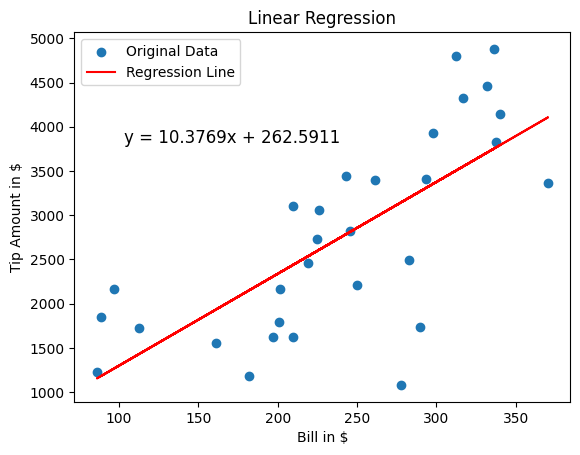

Slope: 10.376861780533357
Intercept: 262.5910805206704
R-squared: 0.5187285290841135
P-Value: 7.209361483313792e-06
Standard Error: 1.8889132296443216
SSR (Sum of Squares Regression): 19195994.084536936
SST (Total Sum of Squares): 37005857.60808278
SSE (Sum of Squares Error): 5.3660187404602766e-11


In [33]:
# Plot the data and the regression line
plt.scatter(x, y, label='Original Data')
plt.plot(x, pridicted_y, label='Regression Line', color='red')
plt.xlabel('Bill in $')
plt.ylabel('Tip Amount in $')
plt.title('Linear Regression')
plt.legend()

# Annotate the regression equation on the chart
equation = f'y = {Slope:.4f}x + {intersept:.4f}'
plt.annotate(equation, xy=(0.1, 0.7), xycoords='axes fraction', fontsize=12)

plt.show()

# Display regression results
print("Slope:", Slope)
print("Intercept:", intersept)
print("R-squared:", r_value ** 2)
print("P-Value:", p_value)
print("Standard Error:", std_err)
print("SSR (Sum of Squares Regression):", ssr)
print("SST (Total Sum of Squares):", sst)
print("SSE (Sum of Squares Error):", sse)
